# FRC Match Metrics
Displays the results of a FRC match in a series of charts

## Setup
In your virtual environment, install pandas and matplotlib: 
  `pip install pandas matplotlib`
* If you are using VS Code, it should ask you to install the IPython extensions.
* If this next cell runs with no errors, you are all set.

In [3]:
import util
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

## Functions to get Team and Event names
Some parts of this notebook depend on a team you are interested in.  Other parts of this notebook need to look up the team name.  This section defines a function to look up the team name.  Same things for event name.

In [4]:
def get_team_name(team_id):
    url = f'https://www.thebluealliance.com/api/v3/team/{team_id}'
    return util.call_tba_api(url).json()['nickname']

def get_event_name(event_id):
    url = f'https://www.thebluealliance.com/api/v3/event/{EVENT_KEY}/simple'
    resp = util.call_tba_api(url).json()
    return str(resp['year']) + ' ' + resp['name']

## Default Team and Event

In [5]:
TEAM = 'frc6223'
EVENT_KEY = '2025wimu'

TEAM_NAME = get_team_name(TEAM)
EVENT_NAME = get_event_name(EVENT_KEY)

print(TEAM_NAME, 'at', EVENT_NAME)

Arsenal of Engineering at 2025 Phantom Lakes Regional


## Team Metrics at one Event
There are three special metrics from TBA at `/oprs`.  The other basic metrics are at `\rankings`.

In this section, we create a Pandas dataframe.  Think about it like a spreadsheet in memory.  There are a couple of techniques used here to best get the data out of the different JSON responses.
1. The OPR metrics are in a dictionary by team, so we can pull them into individual dataframes.
2. The other metrics are in an array by each team, so we have to:

    * Figure out what values they provide.
    * Create a dataframe with those headers
    * Loop through the teams and put the unlabeled values into an array. (I add a calculated one: ranking points)
    * Append that array to the dataframe
3. Then we merge the three dfs from 1 into 2.
4. We add the team name.  This is a pretty powerful syntax.  For each row, it calls a function using the team value and inserts the name value.

In [6]:
# Get calculated rankings
url = f'https://www.thebluealliance.com/api/v3/event/{EVENT_KEY}/oprs'
response = util.call_tba_api(url).json()

df_opr = pd.DataFrame.from_dict(response['oprs'], orient='index', columns=['opr'])
df_dpr = pd.DataFrame.from_dict(response['dprs'], orient='index', columns=['dpr'])
df_ccwm = pd.DataFrame.from_dict(response['ccwms'], orient='index', columns=['ccwm'])

# Get other rankings
url = f'https://www.thebluealliance.com/api/v3/event/{EVENT_KEY}/rankings'
response = util.call_tba_api(url).json()

# Find out what values they have and create a base dataframe
headers = ['team']
for x in response['sort_order_info']:
    headers.append(x['name'])
headers.append('Ranking Points')
df = pd.DataFrame(columns=headers)

# Loop through the teams and add a record with the team's ranking
for r in response['rankings']:
    record = [r['team_key']]
    for x in range(len(headers) - 2):
        record.append(r['sort_orders'][x])
    record.append(r['sort_orders'][0] * r['matches_played'])
    df.loc[len(df.index)] = record

# Merge the original metrics into our most recent dataframe
df = df.merge(df_opr, left_on='team', right_index=True)
df = df.merge(df_dpr, left_on='team', right_index=True)
df = df.merge(df_ccwm, left_on='team', right_index=True)

# Get team names
df['Name'] = df['team'].apply(get_team_name)

# Clean up variables we don't need
del df_ccwm, df_dpr, df_opr, url, response, r, record, x, headers

df

,team,Ranking Score,Avg Coop,Avg Match,Avg Auto,Avg Barge,Ranking Points,opr,dpr,ccwm,Name
0,frc4635,4.88,0.13,147.00,33.25,16.00,39.04,71.506195,14.301143,57.205052,PrepaTec - Botbusters
1,frc2530,4.63,0.13,156.50,36.13,19.00,37.04,76.357380,20.464457,55.892923,Inconceivable
2,frc4607,4.50,0.13,136.00,30.63,14.00,36.00,62.089725,29.657561,32.432164,C.I.S.
3,frc6574,4.25,0.25,117.88,22.38,16.25,34.00,46.951894,49.918416,-2.966523,Ferradermis
4,frc9401,4.25,0.13,110.25,26.25,14.00,34.00,53.464517,37.946657,15.517860,Midas' Mayhem
5,frc1792,4.13,0.00,117.25,23.75,12.50,33.04,44.118741,45.770680,-1.651939,Round Table Robotics
6,frc5934,4.11,0.00,113.22,21.00,19.56,36.99,49.833892,23.945092,25.888800,Crowbotics
7,frc1732,3.63,0.13,126.38,33.00,13.00,29.04,59.116936,64.623937,-5.507000,Hilltopper Robotics
8,frc2077,3.50,0.13,98.63,22.38,9.25,28.00,25.629293,16.999684,8.629609,Laser Robotics
9,frc8701,3.50,0.00,112.63,19.88,13.00,28.00,41.186298,33.515257,7.671041,GRAFFITI


## Function to Draw a Chart
This function draws a horizontal bar chart for the specified column.
Right now, it accesses "global" variables for `TEAM`, `TEAM_NAME` and `EVENT_NAME`.
You only need to run this cell once per session.

In [7]:
# Create a chart given a dataframe and other info
def print_chart(df, col, title, invert=False):
    # First, sort by the column we are interested in
    df = df.sort_values(by=col, ascending=invert, ignore_index=True) 

    # Get the figure and axis variables so we can configure it
    fig, ax = plt.subplots()

    # Create a horizontal bar chart with the data
    hbars = ax.barh(df['team'], df[col], align='center')

    # Highlight the team we are interested in
    i = df[df['team'] == TEAM].index.values[0]
    hbars[i].set_color('r')  

    # Turn off the labels - too noisy
    ax.get_yaxis().set_visible(False)

    # Make it descending - maybe pass this in...
    ax.invert_yaxis()

    # Get our score
    score = df[df['team'] == TEAM][col].values[0]

    team_loc = '#' + str(TEAM).replace('frc','') + ' ' + TEAM_NAME + ' at ' + EVENT_NAME + '\n'

    ax.set_title(team_loc  + title.replace('\n', f' = {score:.2f} (#{i + 1})\n'))
    plt.show()

    print(df[['team', col, 'Name']].iloc[:50])


## Print Charts

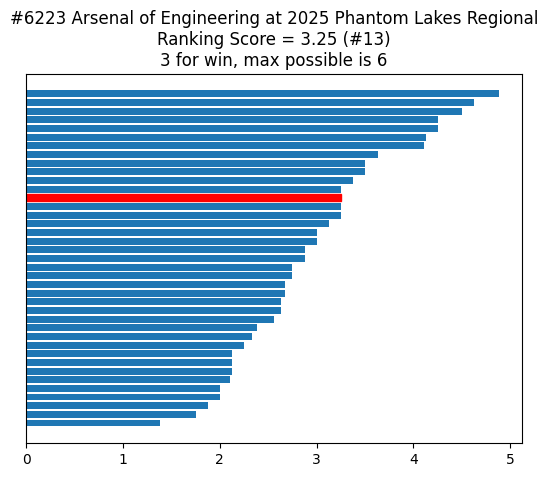

        team  Ranking Score                               Name
0    frc4635           4.88              PrepaTec - Botbusters
1    frc2530           4.63                      Inconceivable
2    frc4607           4.50                             C.I.S.
3    frc6574           4.25                        Ferradermis
4    frc9401           4.25                      Midas' Mayhem
5    frc1792           4.13               Round Table Robotics
6    frc5934           4.11                         Crowbotics
7    frc1732           3.63                Hilltopper Robotics
8    frc8701           3.50                           GRAFFITI
9    frc2077           3.50                     Laser Robotics
10   frc3184           3.38                     Blaze Robotics
11   frc1306           3.25                         BadgerBOTS
12   frc6223           3.25             Arsenal of Engineering
13   frc6317           3.25              Disruptive Innovation
14   frc6381           3.25                Red Raider R

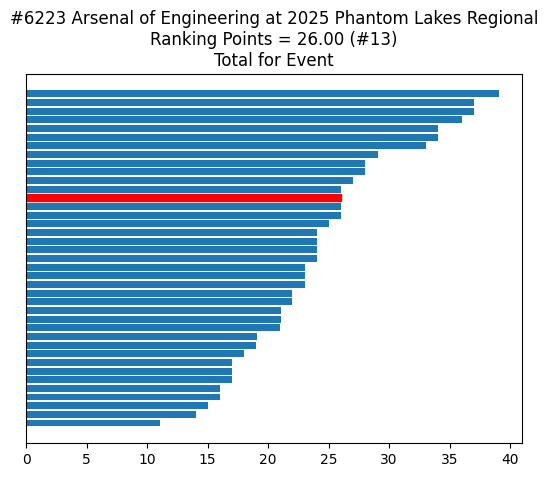

        team  Ranking Points                               Name
0    frc4635           39.04              PrepaTec - Botbusters
1    frc2530           37.04                      Inconceivable
2    frc5934           36.99                         Crowbotics
3    frc4607           36.00                             C.I.S.
4    frc6574           34.00                        Ferradermis
5    frc9401           34.00                      Midas' Mayhem
6    frc1792           33.04               Round Table Robotics
7    frc1732           29.04                Hilltopper Robotics
8    frc2077           28.00                     Laser Robotics
9    frc8701           28.00                           GRAFFITI
10   frc3184           27.04                     Blaze Robotics
11   frc1306           26.00                         BadgerBOTS
12   frc6223           26.00             Arsenal of Engineering
13   frc6317           26.00              Disruptive Innovation
14   frc6381           26.00            

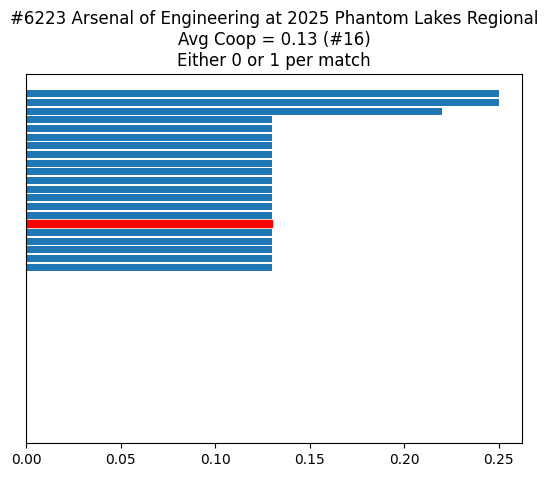

        team  Avg Coop                               Name
0    frc6574      0.25                        Ferradermis
1    frc1714      0.25                      MORE Robotics
2    frc7417      0.22                     Bionic Bombers
3    frc4635      0.13              PrepaTec - Botbusters
4    frc6318      0.13               FE Freedom Engineers
5    frc4693      0.13                   Talk Nerdy to Me
6   frc10553      0.13                   Orange Overdrive
7    frc6166      0.13                        Thorobotics
8    frc1091      0.13                     Oriole Assault
9    frc8700      0.13                          W.I.R.E.D
10   frc2202      0.13                     BEAST Robotics
11   frc6421      0.13                        WarriorBots
12   frc2530      0.13                      Inconceivable
13   frc5993      0.13            Istech Robotics Society
14   frc4607      0.13                             C.I.S.
15   frc6223      0.13             Arsenal of Engineering
16   frc1306  

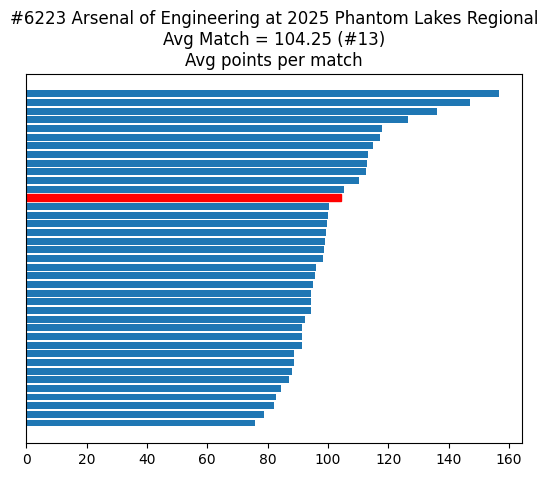

        team  Avg Match                               Name
0    frc2530     156.50                      Inconceivable
1    frc4635     147.00              PrepaTec - Botbusters
2    frc4607     136.00                             C.I.S.
3    frc1732     126.38                Hilltopper Robotics
4    frc6574     117.88                        Ferradermis
5    frc1792     117.25               Round Table Robotics
6    frc1306     114.75                         BadgerBOTS
7    frc5934     113.22                         Crowbotics
8    frc1714     112.75                      MORE Robotics
9    frc8701     112.63                           GRAFFITI
10   frc9401     110.25                      Midas' Mayhem
11   frc6318     105.13               FE Freedom Engineers
12   frc6223     104.25             Arsenal of Engineering
13   frc3354     100.25                PrepaTec - TecDroid
14   frc6317     100.00              Disruptive Innovation
15   frc3184      99.63                     Blaze Roboti

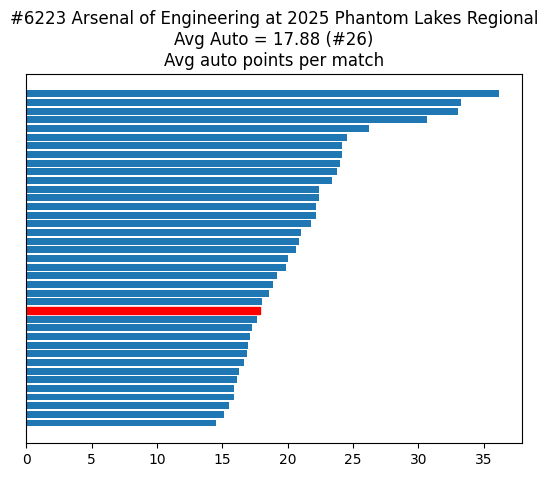

        team  Avg Auto                               Name
0    frc2530     36.13                      Inconceivable
1    frc4635     33.25              PrepaTec - Botbusters
2    frc1732     33.00                Hilltopper Robotics
3    frc4607     30.63                             C.I.S.
4    frc9401     26.25                      Midas' Mayhem
5    frc1714     24.50                      MORE Robotics
6    frc2290     24.13                               FLYT
7    frc6947     24.13                       Savage Tumaz
8    frc4786     24.00                       Nicolet FEAR
9    frc1792     23.75               Round Table Robotics
10   frc3354     23.38                PrepaTec - TecDroid
11   frc6574     22.38                        Ferradermis
12   frc2077     22.38                     Laser Robotics
13   frc6024     22.13                           R Factor
14   frc2202     22.13                     BEAST Robotics
15    frc930     21.75                    Mukwonago BEARs
16   frc5934  

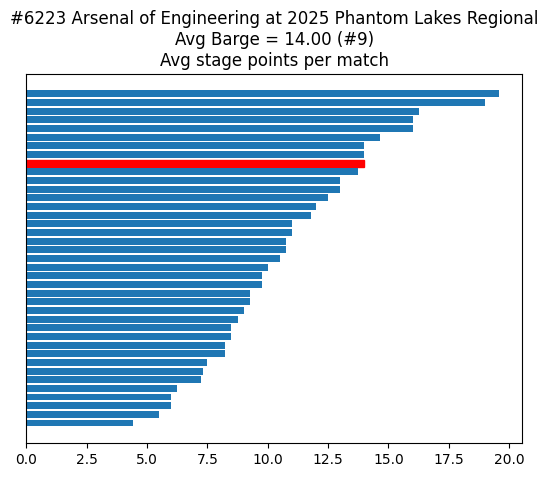

        team  Avg Barge                               Name
0    frc5934      19.56                         Crowbotics
1    frc2530      19.00                      Inconceivable
2    frc6574      16.25                        Ferradermis
3    frc4635      16.00              PrepaTec - Botbusters
4    frc6381      16.00                Red Raider Robotics
5    frc7900      14.67                    Trial N' Terror
6    frc4607      14.00                             C.I.S.
7    frc9401      14.00                      Midas' Mayhem
8    frc6223      14.00             Arsenal of Engineering
9    frc6317      13.75              Disruptive Innovation
10   frc1732      13.00                Hilltopper Robotics
11   frc8701      13.00                           GRAFFITI
12   frc1792      12.50               Round Table Robotics
13    frc930      12.00                    Mukwonago BEARs
14   frc1220      11.78  Rockhoppers - Hilltopper Robotics
15   frc6421      11.00                        WarriorBo

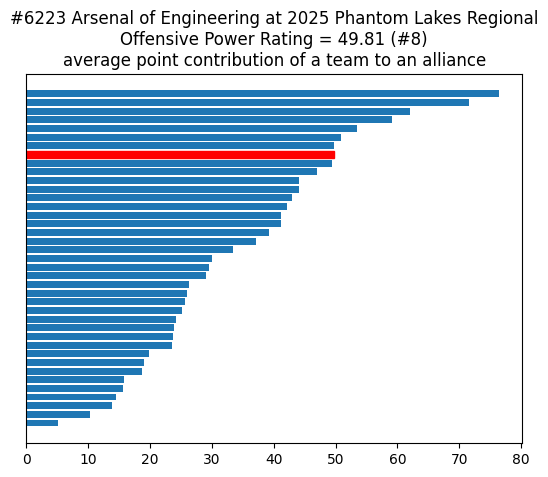

        team        opr                               Name
0    frc2530  76.357380                      Inconceivable
1    frc4635  71.506195              PrepaTec - Botbusters
2    frc4607  62.089725                             C.I.S.
3    frc1732  59.116936                Hilltopper Robotics
4    frc9401  53.464517                      Midas' Mayhem
5    frc6317  50.905878              Disruptive Innovation
6    frc5934  49.833892                         Crowbotics
7    frc6223  49.813013             Arsenal of Engineering
8    frc1714  49.367777                      MORE Robotics
9    frc6574  46.951894                        Ferradermis
10   frc1792  44.118741               Round Table Robotics
11   frc3354  44.112746                PrepaTec - TecDroid
12   frc1306  43.011306                         BadgerBOTS
13   frc6421  42.230951                        WarriorBots
14   frc8701  41.186298                           GRAFFITI
15   frc6318  41.170331               FE Freedom Enginee

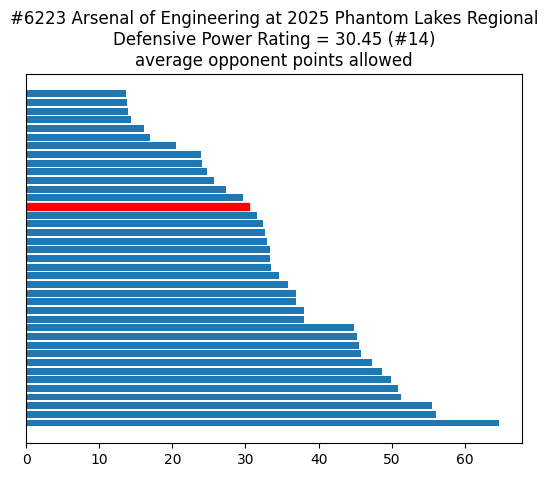

        team        dpr                               Name
0    frc6947  13.722064                       Savage Tumaz
1   frc10264  13.743222                              STORM
2    frc4786  13.875826                       Nicolet FEAR
3    frc4635  14.301143              PrepaTec - Botbusters
4    frc6643  16.118833                  Walnuts and Bolts
5    frc2077  16.999684                     Laser Robotics
6    frc2530  20.464457                      Inconceivable
7    frc5934  23.945092                         Crowbotics
8    frc2290  24.001081                               FLYT
9    frc6421  24.717161                        WarriorBots
10   frc1220  25.749559  Rockhoppers - Hilltopper Robotics
11   frc6024  27.331479                           R Factor
12   frc4607  29.657561                             C.I.S.
13   frc6223  30.454994             Arsenal of Engineering
14   frc7417  31.637491                     Bionic Bombers
15   frc2062  32.402849                          CORE 20

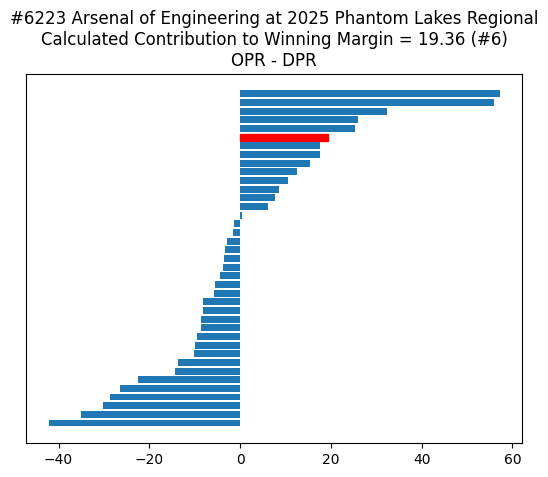

        team       ccwm                               Name
0    frc4635  57.205052              PrepaTec - Botbusters
1    frc2530  55.892923                      Inconceivable
2    frc4607  32.432164                             C.I.S.
3    frc5934  25.888800                         Crowbotics
4    frc4786  25.432590                       Nicolet FEAR
5    frc6223  19.358018             Arsenal of Engineering
6    frc6317  17.551425              Disruptive Innovation
7    frc6421  17.513789                        WarriorBots
8    frc9401  15.517860                      Midas' Mayhem
9    frc1714  12.437609                      MORE Robotics
10   frc6947  10.548596                       Savage Tumaz
11   frc2077   8.629609                     Laser Robotics
12   frc8701   7.671041                           GRAFFITI
13   frc2290   6.043340                               FLYT
14   frc1220   0.503841  Rockhoppers - Hilltopper Robotics
15   frc3354  -1.423862                PrepaTec - TecDro

In [10]:
print_chart(df, 'Ranking Score', 'Ranking Score\n3 for win, max possible is 6')
print_chart(df, 'Ranking Points', 'Ranking Points\nTotal for Event')
print_chart(df, 'Avg Coop', 'Avg Coop\nEither 0 or 1 per match')
print_chart(df, 'Avg Match', 'Avg Match\nAvg points per match')
print_chart(df, 'Avg Auto', 'Avg Auto\nAvg auto points per match')
print_chart(df, 'Avg Barge', 'Avg Barge\nAvg stage points per match')

print_chart(df, 'opr', 'Offensive Power Rating\naverage point contribution of a team to an alliance')
print_chart(df, 'dpr', 'Defensive Power Rating\naverage opponent points allowed', True)
print_chart(df, 'ccwm', 'Calculated Contribution to Winning Margin\nOPR - DPR')

## Count Undefeated Teams

In [9]:
year = '2025'
url = f'https://www.thebluealliance.com/api/v3/events/{year}/simple'
events = util.call_tba_api(url).json()
event_count = 0
team_appearances = 0
undefeated = 0
undefeated_teams = []
teams_list = []
for e in events:
    # Event type: 0 - regional, 1 - district...
    if datetime.strptime(e['end_date'], "%Y-%m-%d") < datetime.now() and e['event_type'] == 0:
        event_count += 1
        event_code = year + e['event_code']
        print(event_code, e['end_date'], e['name'])

        url = f'https://www.thebluealliance.com/api/v3/event/{event_code}/rankings'
        rankings = util.call_tba_api(url).json()
        teams = 0
        for r in rankings['rankings']:
            teams += 1
            teams_list.append(r['team_key'])
            if r['record']['wins'] > 0 and r['record']['losses'] == 0 and r['record']['ties'] == 0:
                team_key = r['team_key']
                undefeated_teams.append(team_key)
                url = f'https://www.thebluealliance.com/api/v3/team/{team_key}'
                t = util.call_tba_api(url).json()
                print('  ', team_key, r['rank'], t['nickname'], t['city'], t['state_prov'] )
                undefeated += 1
        team_appearances += teams
        print('  ', teams, 'teams')

utc = len(set(undefeated_teams))
tc = len(set(teams_list))

# Clean up variables
# del e, events, t, team_key, teams, url, year, event_code

print('Events:', event_count)
print('Team appearances:', team_appearances)
# print('Undefeated:', undefeated, f'{undefeated/team_appearances:.1%}')
print(f'Unique undefeated teams: {utc} of {tc} ({utc/tc:.1%})')


 

2025alhu 2025-03-15 Rocket City Regional
   frc2338 1 Gear It Forward Oswego Illinois
   44 teams
2025arli 2025-03-08 Arkansas Regional
   frc2481 1 Roboteers Tremont Illinois
   30 teams
2025ausc 2025-03-09 Southern Cross Regional
   41 teams
2025azfg 2025-03-15 Arizona North Regional
   40 teams
2025azgl 2025-03-22 Arizona East Regional
   frc5026 1 Iron Panthers Burlingame California
   42 teams
2025bcvi 2025-03-01 Canadian Pacific Regional
   frc359 1 Hawaiian Kids Waialua Hawaii
   48 teams
2025brba 2025-03-15 Regional Brazil - Brasilia
   frc7563 1 SESI SENAI MEGAZORD Jundiaí São Paulo
   frc1860 2 Alphabots Sao Jose dos Campos São Paulo
   59 teams
2025brsp 2025-03-23 Regional Brazil - São Paulo
   frc1156 1 Under Control Novo Hamburgo Rio Grande do Sul
   33 teams
2025cada 2025-03-17 Sacramento Regional
   34 teams
2025cala 2025-03-16 Los Angeles Regional
   43 teams
2025camb 2025-03-02 Pinnacles Regional
   35 teams
2025caoc 2025-03-01 Orange County Regional
   47 teams
2025ca